# Statistical Analysis of Retinal Signal Variability

## Objective

This notebook investigates statistical properties of simulated retinal signal behavior and neural variability.

## Methods

The notebook uses:
- NumPy for signal simulation
- statistical summaries such as mean, variance, and distribution analysis
- Matplotlib for visualizing signal variability

## Biological Context

Statistical analysis is essential for understanding variability in biological systems. Retinal signals may vary across time, cells, and conditions, making quantitative analysis important for computational neuroscience.

## Expected Outcome

The notebook is expected to characterize variability in retinal-like signals using basic statistical measures and visualizations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time = np.linspace(0, 10, 500)

clean_signal = np.sin(time)
low_noise = clean_signal + np.random.normal(0, 0.15, len(time))
high_noise = clean_signal + np.random.normal(0, 0.45, len(time))

signals = pd.DataFrame({
    "Clean_Signal": clean_signal,
    "Low_Noise": low_noise,
    "High_Noise": high_noise
})

signals.describe()

,Clean_Signal,Low_Noise,High_Noise
count,500.000000,500.000000,500.000000
mean,0.182989,0.184015,0.197311
std,0.666276,0.679254,0.823114
min,-0.999996,-1.344868,-1.823670
25%,-0.395843,-0.387457,-0.349378
50%,0.312943,0.290280,0.251188
75%,0.809538,0.791776,0.825806
max,0.999999,1.289848,2.108754


In [2]:
correlation_matrix = signals.corr()
correlation_matrix

,Clean_Signal,Low_Noise,High_Noise
Clean_Signal,1.000000,0.976251,0.845840
Low_Noise,0.976251,1.000000,0.817154
High_Noise,0.845840,0.817154,1.000000


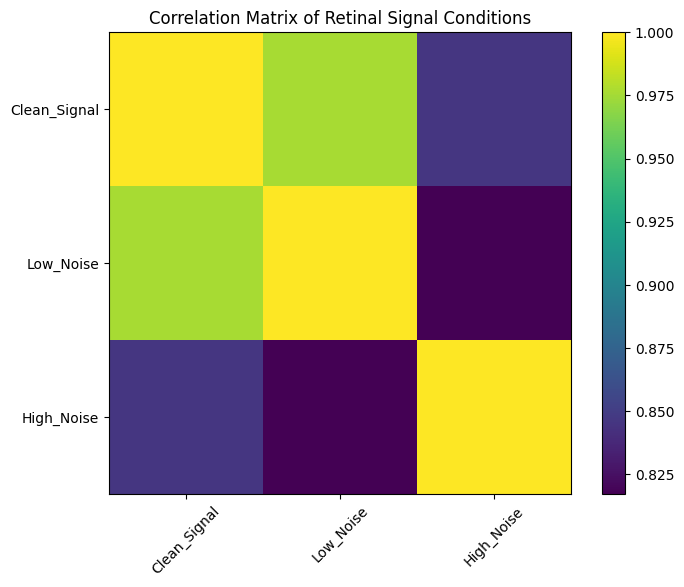

In [3]:
plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Correlation Matrix of Retinal Signal Conditions")

plt.show()

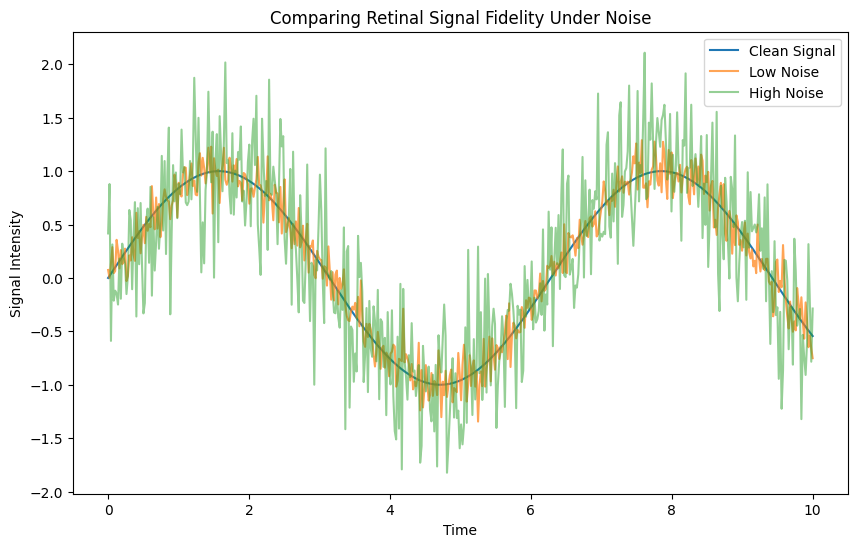

In [4]:
plt.figure(figsize=(10,6))

plt.plot(time, clean_signal, label="Clean Signal")
plt.plot(time, low_noise, label="Low Noise", alpha=0.7)
plt.plot(time, high_noise, label="High Noise", alpha=0.5)

plt.title("Comparing Retinal Signal Fidelity Under Noise")
plt.xlabel("Time")
plt.ylabel("Signal Intensity")
plt.legend()

plt.show()